In [1]:

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from IPython.display import display, Markdown, Latex
import pandas as pd
from uncertainties import ufloat
from uncertainties import unumpy as unp
from uncertainties.umath import sqrt
from scipy.optimize import curve_fit
from scipy import constants as const 
from matplotlib.ticker import MaxNLocator

# PW12


## Experiment 1:
Im ersten Versuch wird die freie und die angeregte mechanische Schwingung untersucht. Für die Erstere wird dabei die die Schwingungsdauer und daraus die Eigenkreisfrequenz aus bekannten Zusammenhängen berechnet. Zudem wird die Dämpfungskonstante hier durch den Anstieg des linearen Fits aus aufeinanderfolgenden Amplituden und deren Zeiten bestimmt. Die zentrale Formel lautet dafür: 

$$
\ln\!\left(\frac{x_i}{x_0}\right) = -\delta \cdot t_i
$$

Bei der angeregten Schwingung wird durch Erregerfrequenzen um die Eigenkreisfrequenz eine Amplitudenresonanzkurve gemäß folgendem Zusammenhang erstellt:

$$
U(\omega) = \frac{U_0 \, \omega_0^{2}}
{\sqrt{(\omega_0^{2} - \omega^{2})^{2} + (2\delta \omega)^{2}}}
$$

Aus dem Fit lässt sich aus der Halbwertsbreite der Resonanzkurve die Dämpfung für die Schwingung mit Erregerfrequenz berechnen. Zusätzlich soll die Güte für beide Versuche berechnet und miteinander verglichen werden, wobei diese wie folgt zu berechnen ist: 

$$
Q \approx \frac{\omega_0}{2\delta}
$$

Die Schwingkreisfrequenz beträgt (3.4334+/-0.0375)rad/s.
Die Dämpfungskonstante beträgt (0.19696+/-0.00263)1/s.


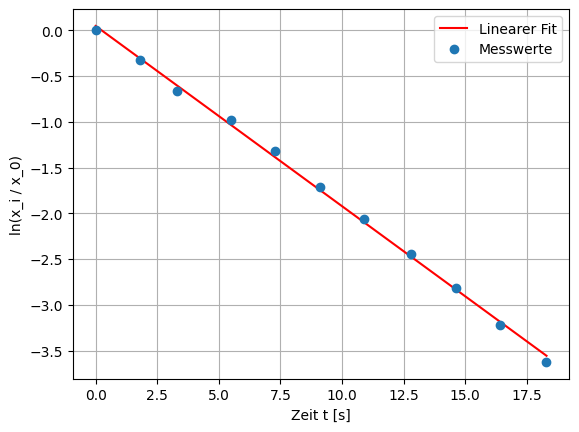

Die Eigenfrequenz beträgt (3.4391+/-0.0375)rad/s.


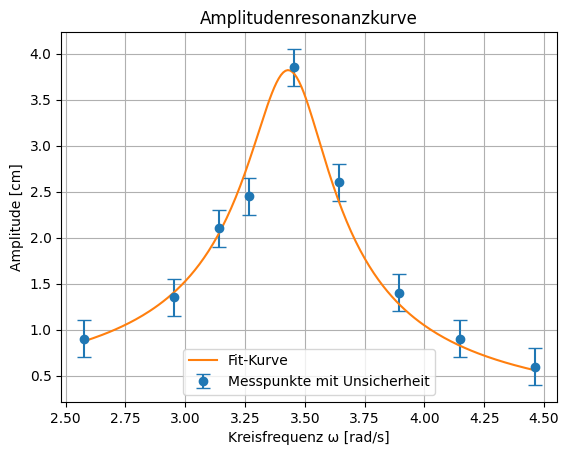

Die Dämpfung aus der Halbwertsbreite beträgt (0.1759+/-0.0300)1/s.
Die Güte für die freie Schwingung beträgt (8.731+/-0.150).
Die Güte für die angeregte Schwingung beträgt (9.778+/-1.671).


In [24]:
# 1. Experiment zur Untersuchung freier und erzwungener Schwingungen

# Bestimmung der Schwingkreisfrequenz und der Dämpfungskonstante

# Zeiten der Maxima [s]
t = np.array([0.0, 1.81, 3.31, 5.51, 7.3, 9.11, 10.9, 12.81, 14.61, 16.4, 18.3])

# Amplituden der Maxima
x_val = np.array([15, 10.8, 7.7, 5.6, 4, 2.7, 1.9, 1.3, 0.9, 0.6, 0.4])
sigma_x = 0.2 # Ableseunsicherheit der Amplituden
x = unp.uarray(x_val, sigma_x)

t10 = ufloat(t[10], 0.2)
T = t10/10 # Periodendauer 
f = 1 / T # Frequenz          
omega = 2 * np.pi * f # Kreisfrequenz

print(f"Die Schwingkreisfrequenz beträgt ({omega:.4f})rad/s.")

# Bestimmung der Dämpfungskonstante

x0 = x[0]
y = unp.log(x / x0)

res = linregress(t, unp.nominal_values(y))
delta = -res.slope
sigma_delta = res.stderr
d_u = ufloat(delta, sigma_delta)


print(f"Die Dämpfungskonstante beträgt ({d_u:.5f})1/s.")

# Plot
y_nom = unp.nominal_values(y)
# y_err = unp.std_devs(y)

plt.errorbar(t, y_nom, fmt='o', label="Messwerte", capsize = 4)
plt.plot(t, res.slope*t + res.intercept, 'r', label="Linearer Fit")
plt.xlabel("Zeit t [s]")
plt.ylabel("ln(x_i / x_0)")
plt.legend()
plt.grid()
plt.show()

# Berechnen der Eigenfrequenz des Pendels
w0 = sqrt((omega**2) + (d_u**2))
print(f"Die Eigenfrequenz beträgt ({w0:.4f})rad/s.")

# Bestimmung der Amplitudenresonanzkurve und Dämpfung bei erzwungener Schwingung

#  Frequenzen in Schwingungen pro Minute
f_rpm = np.array([0.41, 0.47, 0.5, 0.52, 0.55, 0.58, 0.62, 0.66, 0.71])
# Umrechnen in Hz
# f_Hz = f_rpm / 60
# Kreisfrequenz in rad/s für Plot oder Fit
omega = 2 * np.pi * f_rpm # ist jetzt ein Array mit den Frequenzen
omega = np.array(omega, dtype=float)
A_meas = np.array([0.9, 1.35, 2.1, 2.45, 3.85, 2.6, 1.4, 0.9, 0.6], dtype=float) # jeweiligen Amplitudenwerte in cm
A_err = np.array([0.2] * len(A_meas))

w0_fit = unp.nominal_values(w0)

def A_fit(omega, U0, delta):
    return (U0*w0_fit**2) / np.sqrt((w0_fit**2 - omega**2)**2 + (2*delta*omega)**2)

# Curve-Fit
popt, _ = curve_fit(A_fit, omega, A_meas, p0=[2, 0.1])
U0_fit, delta_fit = popt

# Glatte Kurve für Plot
omega_smooth = np.linspace(min(omega), max(omega), 200)
A_smooth = A_fit(omega_smooth, U0_fit, delta_fit)

# Plot
plt.errorbar(omega, A_meas, yerr=A_err, fmt='o', capsize=5, label='Messpunkte mit Unsicherheit')
plt.plot(omega_smooth, A_smooth, '-', label='Fit-Kurve')
# plt.plot(omega, A_meas, 'o', label='Messpunkte')
plt.xlabel('Kreisfrequenz ω [rad/s]')
plt.ylabel('Amplitude [cm]')
plt.title('Amplitudenresonanzkurve')
plt.legend()
plt.grid(True)
plt.show()

# Bestimmung der Dämpfungskonstante aus der angeregten Schwingung

# Feine Frequenzachse
omega_fine = np.linspace(omega.min(), omega.max(), 2000)
A_fine = A_fit(omega_fine, U0_fit, delta_fit)

# Maximum und Halbwert
A_max = A_fine.max()
A_half = A_max / np.sqrt(2)

# Indizes der Schnittpunkte mit A_half
idx = np.where(np.diff(np.sign(A_fine - A_half)))[0]

# Halbwertsfrequenzen
omega_1 = omega_fine[idx[0]]
omega_2 = omega_fine[idx[1]]

# Halbwertsbreite und Dämpfung
# Frequenzauflösung
domega = omega_fine[1] - omega_fine[0]

# Halbwertsfrequenzen mit Unsicherheit
omega_1_u = ufloat(omega_1, domega/2)
omega_2_u = ufloat(omega_2, domega/2)

# Halbwertsbreite und Dämpfung mit Unsicherheit
Delta_omega_u = omega_2_u - omega_1_u
delta_HW_u = Delta_omega_u / 2

# Unsicherheit für Dämpfung anpassen, da Amplitudenunsicherheit sehr groß
delta_HW = unp.nominal_values(delta_HW_u)
delta_HW_U = ufloat(delta_HW, 0.03)

print(f"Die Dämpfung aus der Halbwertsbreite beträgt ({delta_HW_U:.4f})1/s.")

# Bestimmung der Güte für die erregte und freie Schwingung

Q1 = w0/(2*d_u) # freie Schwingung
Q2 = w0/(2*delta_HW_U) # angeregte Schwingung

print(f"Die Güte für die freie Schwingung beträgt ({Q1:.3f}).")
print(f"Die Güte für die angeregte Schwingung beträgt ({Q2:.3f}).")

## Experiment 2

Im zweiten Versuch soll eine gekoppelte Schwingung untersucht werden, wobei zunächst die Kopplungs- und Pendellänge sowie das Kopplungsgewicht ermittelt wird. Danach wird im Schwebungsfall die Schwebungs- und Umlaufdauer experimentell bestimmt. Aus diesen lassen sich erneut aus den bekannten Zusammenhängen die jeweiligen Kreisfrequenzen berechnen, welche widerum dazu dienen, den Kopplungsgrad K gemäß dem folgenden Zusammenhang zu bestimmen: 

$$
K = \frac{2\,\omega_S\,\omega^{2}}{\omega_S^{2} + \omega^{2}}
$$

In [ ]:
# Untersuchung der gekoppelten Schwingung

#l_k = ufloat(8, 0.1) # Kopplungslänge in cm
#l_p = ufloat(16, 0.1) # Pendellänge in cm
#m_k = ufloat(34, 0.1) # Gewicht in Gramm

#print(f"Die Kopplungslänge beträgt ({l_k})cm.")
#print(f"Die Pendellänge beträgt ({l_p})cm.")
#print(f"Das Kopplungsgewicht hat eine Masse von ({l_k})g.")

t_s = ufloat(43.2, 2) # Schwebungsdauer zwischen zwei Stillständen des selben Pendels
ws = np.pi/t_s

t_2 = ufloat(34.1, 2)/20 # Zeit durch Anzahl der gebrauchten Schwingungen
f_2 = 1/t_2
w2 = 2*np.pi*f_2

w0 = w2 - ws
w1 = ws + w2


# Berechnung Kopplungsgrad K
K = (2*ws*w2)/(ws**2+w2**2)
print(f"Der Kopplungsgrad beträgt ({K:.3f}).")
print(f"Die Eigenfrequenz w0 beträgt ({w0:.3f}) 1/s.")
print(f"Die Eigenfrequenz w1 beträgt ({w1:.3f}) 1/.")
print(f"Die charakteristische Frequenz w2 beträgt ({w2:.3f}) 1/s.")
print(f"Die charakteristische Frequenz ws beträgt ({ws:.3f}) 1/s.")



Der Kopplungsgrad beträgt (0.039+/-0.003).
Die Eigenfrequenz w0 beträgt (3.612+/-0.216) 1/s
Die Eigenfrequenz w1 beträgt (3.758+/-0.216) 1/s
Die charakteristische Frequenz w2 beträgt (3.685+/-0.216) 1/s
Die charakteristische Frequenz ws beträgt (0.073+/-0.003) 1/s
